# 01 — UrbanSound8K Data Exploration

Explore the UrbanSound8K dataset: class distribution, sample waveforms, spectrograms, and MFCC features.

**Dataset**: [UrbanSound8K](https://urbansounddataset.weebly.com/urbansound8k.html) — 8,732 labeled sound clips (≤4s) of urban sounds across 10 classes.

**Setup**: Download UrbanSound8K and extract to `data/UrbanSound8K/` in the project root.

In [12]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.insert(0, '/content/drive/MyDrive/NYC-cafe-study-friendliness')

!pip install librosa soundfile scikit-learn -q

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import sys
import os
from pathlib import Path

PROJECT_ROOT = '/content/drive/MyDrive/NYC-cafe-study-friendliness'

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import IPython.display as ipd

from src.dataset import load_metadata, load_audio, CLASS_NAMES
from src.audio_features import extract_mfcc, extract_mel_spectrogram

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 4)

DATA_DIR = os.path.join(PROJECT_ROOT, "data", "UrbanSound8K")

## 1. Load Metadata and Class Distribution

In [15]:
# Load metadata
df = load_metadata(DATA_DIR)
print(f"Total clips: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"Folds: {sorted(df['fold'].unique())}")
df.head()

Total clips: 8732
Columns: ['slice_file_name', 'fsID', 'start', 'end', 'salience', 'fold', 'classID', 'class']
Folds: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


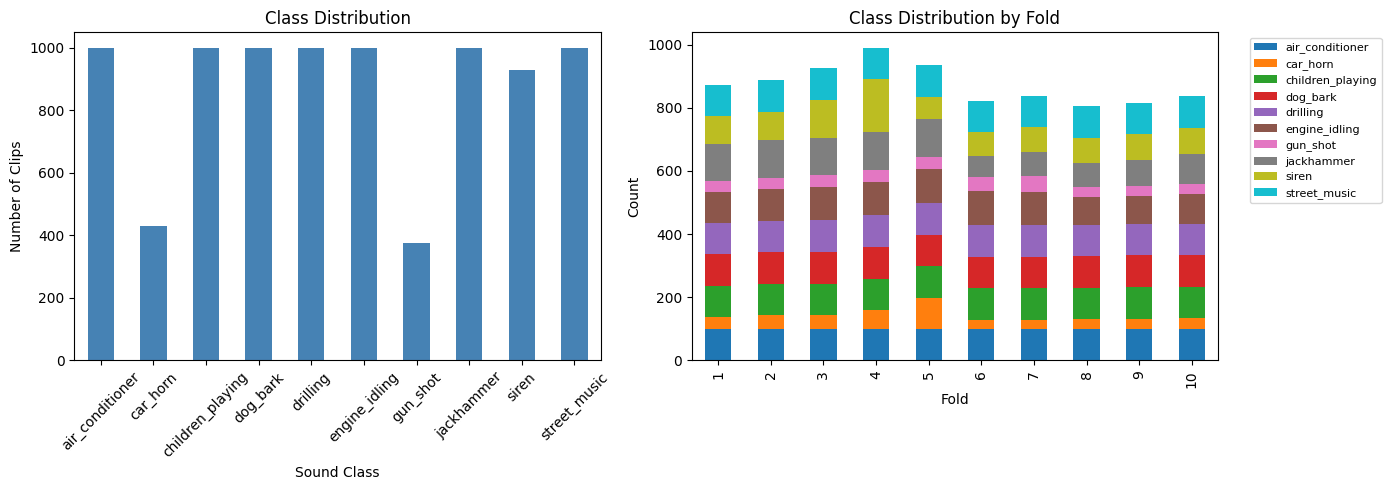

In [16]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
class_counts = df["class"].value_counts().sort_index()
ax = axes[0]
class_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Class Distribution")
ax.set_xlabel("Sound Class")
ax.set_ylabel("Number of Clips")
ax.tick_params(axis="x", rotation=45)

# Per-fold distribution
ax = axes[1]
fold_class = df.groupby(["fold", "class"]).size().unstack(fill_value=0)
fold_class.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
ax.set_title("Class Distribution by Fold")
ax.set_xlabel("Fold")
ax.set_ylabel("Count")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

## 2. Sample Waveforms and Spectrograms

Listen to and visualize one sample from each class.

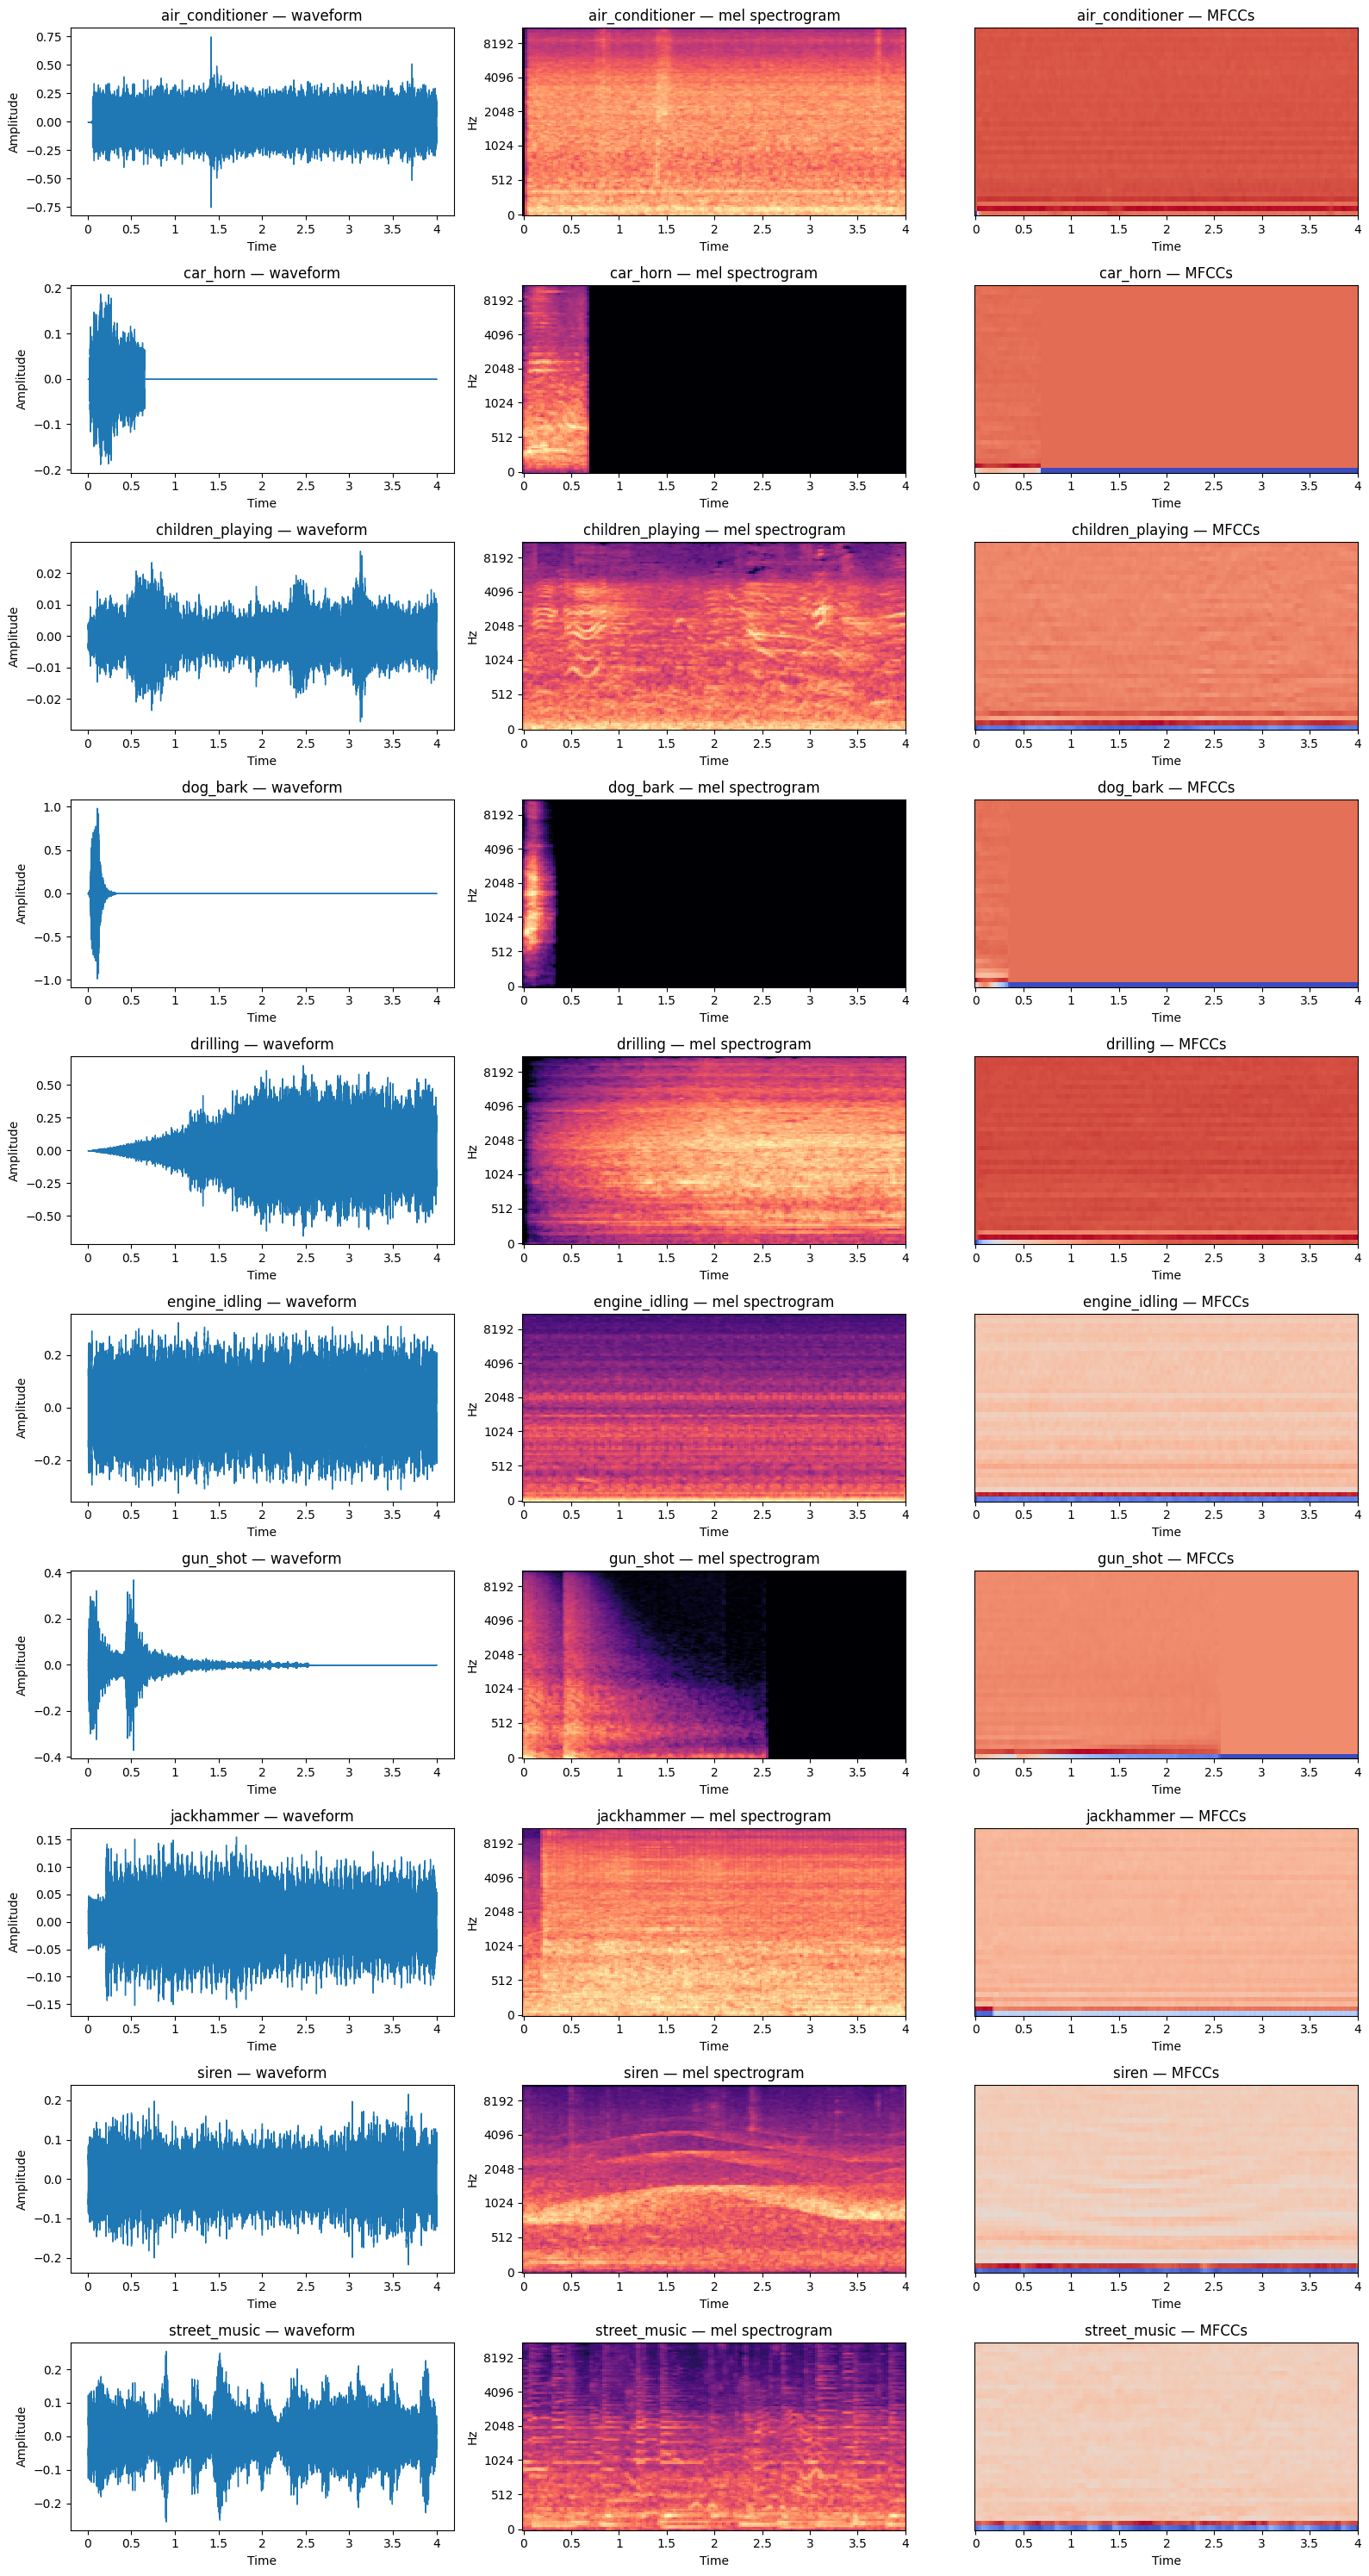

In [17]:
SR = 22050
DURATION = 4.0

# Pick one sample per class
samples = df.groupby("classID").first().reset_index()

fig, axes = plt.subplots(len(samples), 3, figsize=(16, 3 * len(samples)))

for i, (_, row) in enumerate(samples.iterrows()):
    file_path = os.path.join(DATA_DIR, "audio", f"fold{row['fold']}", row["slice_file_name"])
    y = load_audio(file_path, sr=SR, duration=DURATION)
    class_name = CLASS_NAMES[row["classID"]]

    # Waveform
    ax = axes[i, 0]
    librosa.display.waveshow(y, sr=SR, ax=ax)
    ax.set_title(f"{class_name} — waveform")
    ax.set_ylabel("Amplitude")

    # Mel spectrogram
    ax = axes[i, 1]
    mel_spec = extract_mel_spectrogram(y, sr=SR)
    librosa.display.specshow(mel_spec, sr=SR, hop_length=512, x_axis="time", y_axis="mel", ax=ax)
    ax.set_title(f"{class_name} — mel spectrogram")

    # MFCCs
    ax = axes[i, 2]
    mfcc = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=40)
    librosa.display.specshow(mfcc, sr=SR, hop_length=512, x_axis="time", ax=ax)
    ax.set_title(f"{class_name} — MFCCs")

plt.tight_layout()
plt.show()

## 3. Listen to Samples

Play audio for a few representative clips.

In [18]:
# Play one sample from each class
for _, row in samples.iterrows():
    file_path = os.path.join(DATA_DIR, "audio", f"fold{row['fold']}", row["slice_file_name"])
    y = load_audio(file_path, sr=SR, duration=DURATION)
    class_name = CLASS_NAMES[row["classID"]]
    print(f"Class: {class_name}")
    ipd.display(ipd.Audio(y, rate=SR))

Class: air_conditioner


Class: car_horn


Class: children_playing


Class: dog_bark


Class: drilling


Class: engine_idling


Class: gun_shot


Class: jackhammer


Class: siren


Class: street_music


## 4. MFCC Feature Distribution by Class

Visualize how MFCC features differ across classes — this motivates the baseline model.

Extracted features for 1000 clips


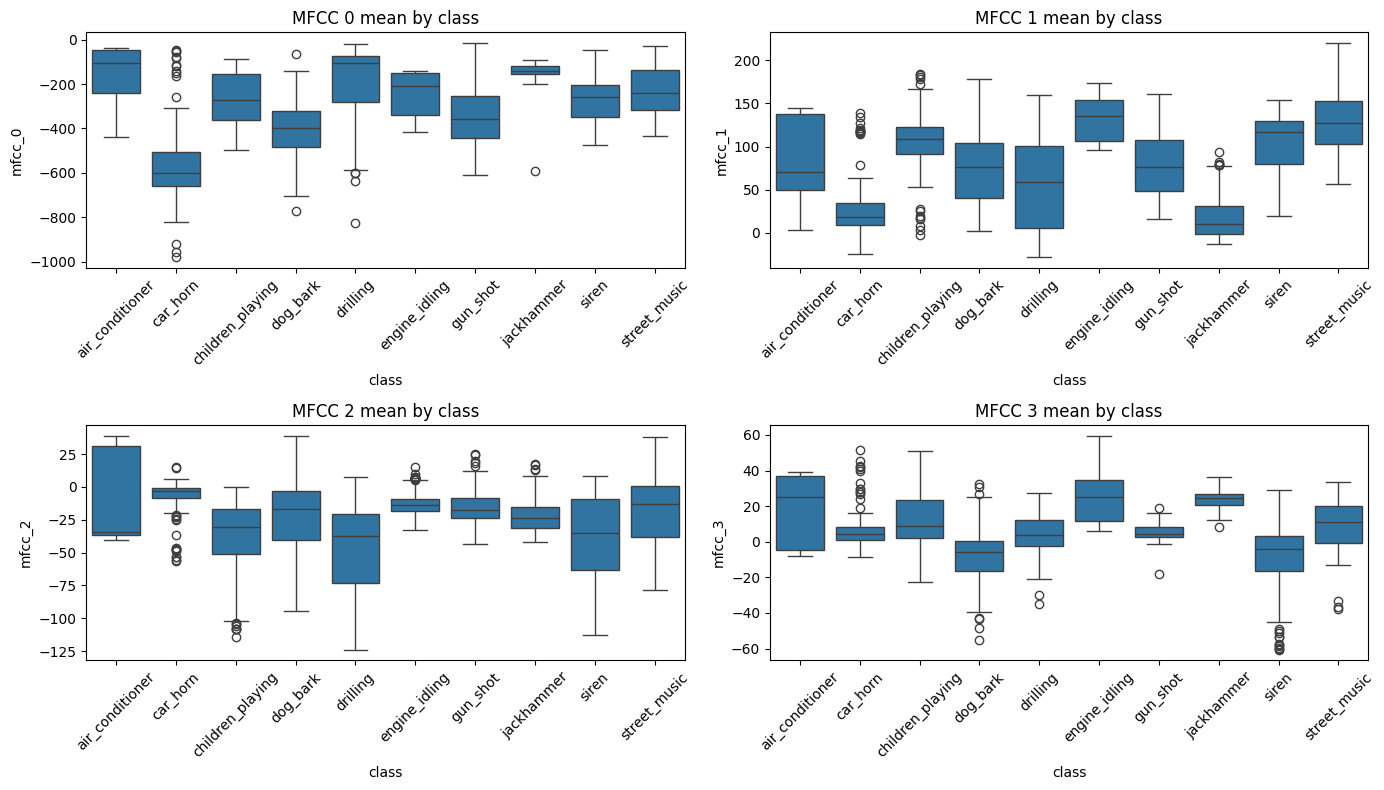

In [19]:
# Extract MFCCs for a subset of clips (100 per class for speed)
from src.audio_features import extract_mfcc

mfcc_data = []
n_per_class = 100

for class_id in range(10):
    class_df = df[df["classID"] == class_id].head(n_per_class)
    for _, row in class_df.iterrows():
        file_path = os.path.join(DATA_DIR, "audio", f"fold{row['fold']}", row["slice_file_name"])
        try:
            y = load_audio(file_path, sr=SR, duration=DURATION)
            # extract_mfcc returns shape (n_mfcc * 6,):
            # layout = [mfcc_mean x13, mfcc_std x13, delta_mean x13, delta_std x13, delta2_mean x13, delta2_std x13]
            # feats[0:13] are the MFCC means — used below for visualization
            feats = extract_mfcc(y, sr=SR, n_mfcc=13)
            mfcc_data.append({"class": CLASS_NAMES[class_id], **{f"mfcc_{i}": feats[i] for i in range(13)}})
        except Exception:
            continue

mfcc_df = pd.DataFrame(mfcc_data)
print(f"Extracted features for {len(mfcc_df)} clips")

# Plot first 4 MFCC means by class
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for i, ax in enumerate(axes.flat):
    sns.boxplot(data=mfcc_df, x="class", y=f"mfcc_{i}", ax=ax)
    ax.set_title(f"MFCC {i} mean by class")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 5. Clip Duration Distribution

UrbanSound8K clips vary in length (up to 4 seconds). Check the distribution.

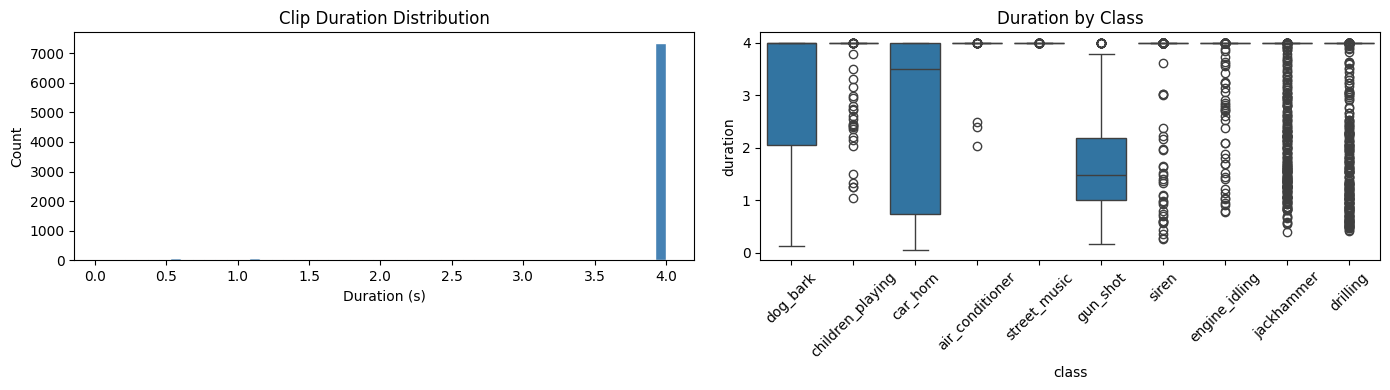

Duration stats:
count    8732.000000
mean        3.607904
std         0.973570
min         0.054517
25%         4.000000
50%         4.000000
75%         4.000000
max         4.000000
Name: duration, dtype: float64


In [20]:
# Clip durations from metadata
df["duration"] = df["end"] - df["start"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["duration"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Clip Duration Distribution")
axes[0].set_xlabel("Duration (s)")
axes[0].set_ylabel("Count")

sns.boxplot(data=df, x="class", y="duration", ax=axes[1])
axes[1].set_title("Duration by Class")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"Duration stats:\n{df['duration'].describe()}")